# Exploração dos rasters SoilGrids

Este notebook inventaria e visualiza os 12 GeoTIFFs Bronze: argila, areia, carbono orgânico e densidade aparente em três profundidades. Os valores permanecem nas unidades e fatores de conversão da fonte.

## Inventário e metadados espaciais

Cada raster é aberto sem transformação para verificar dimensões, CRS, resolução, tipo, valor `nodata` e extensão. Propriedade e profundidade são extraídas da estrutura determinística de diretórios.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio

PROJECT_ROOT = Path(".") if Path("data").exists() else Path("..")
SOIL_ROOT = PROJECT_ROOT / "data/bronze/soilgrids/municipality_code=5107925"
RASTER_PATHS = sorted(SOIL_ROOT.glob("property=*/depth=*/*.tif"))
if not RASTER_PATHS:
    raise FileNotFoundError(
        f"Nenhum raster SoilGrids encontrado em {SOIL_ROOT}. Execute a ingestão primeiro."
    )

inventory_rows = []
for path in RASTER_PATHS:
    property_name = path.parents[1].name.split("=", 1)[1]
    depth = path.parent.name.split("=", 1)[1]
    with rasterio.open(path) as source:
        inventory_rows.append(
            {
                "property": property_name,
                "depth": depth,
                "width": source.width,
                "height": source.height,
                "crs": str(source.crs),
                "pixel_width": source.res[0],
                "pixel_height": source.res[1],
                "dtype": source.dtypes[0],
                "nodata": source.nodata,
            }
        )

inventory = pd.DataFrame(inventory_rows)
print(f"Rasters encontrados: {len(inventory)}")
inventory

Rasters encontrados: 12


,property,depth,width,height,crs,pixel_width,pixel_height,dtype,nodata
0,bdod,0-5cm,463,863,None,249.792808,249.998036,int16,None
1,bdod,15-30cm,463,863,None,249.792808,249.998036,int16,None
2,bdod,5-15cm,463,863,None,249.792808,249.998036,int16,None
3,clay,0-5cm,463,863,None,249.792808,249.998036,int16,None
4,clay,15-30cm,463,863,None,249.792808,249.998036,int16,None
5,clay,5-15cm,463,863,None,249.792808,249.998036,int16,None
6,sand,0-5cm,463,863,None,249.792808,249.998036,int16,None
7,sand,15-30cm,463,863,None,249.792808,249.998036,int16,None
8,sand,5-15cm,463,863,None,249.792808,249.998036,int16,None
9,soc,0-5cm,463,863,None,249.792808,249.998036,int16,None


## Unidades e fatores de conversão

O SoilGrids codifica valores inteiros para reduzir o tamanho dos arquivos. Argila e areia usam `g/kg` com fator 10; carbono orgânico usa `dg/kg` com fator 10; densidade aparente usa `cg/cm³` com fator 100. As estatísticas abaixo mostram tanto o valor armazenado quanto o valor físico convertido apenas em memória.

In [2]:
PROPERTY_METADATA = {
    "clay": {"unit": "g/kg", "factor": 10},
    "sand": {"unit": "g/kg", "factor": 10},
    "soc": {"unit": "dg/kg", "factor": 10},
    "bdod": {"unit": "cg/cm³", "factor": 100},
}

statistic_rows = []
for path in RASTER_PATHS:
    property_name = path.parents[1].name.split("=", 1)[1]
    depth = path.parent.name.split("=", 1)[1]
    metadata = PROPERTY_METADATA[property_name]
    with rasterio.open(path) as source:
        values = source.read(1, masked=True)
    valid_values = values.compressed()
    statistic_rows.append(
        {
            "property": property_name,
            "depth": depth,
            "unit": metadata["unit"],
            "valid_pixels": valid_values.size,
            "null_pixels": int(np.ma.count_masked(values)),
            "stored_minimum": float(valid_values.min()),
            "physical_mean": float(valid_values.mean() / metadata["factor"]),
            "physical_maximum": float(valid_values.max() / metadata["factor"]),
        }
    )

statistics = pd.DataFrame(statistic_rows)
statistics

,property,depth,unit,valid_pixels,null_pixels,stored_minimum,physical_mean,physical_maximum
0,bdod,0-5cm,cg/cm³,399569,0,0.0,1.216770,1.37
1,bdod,15-30cm,cg/cm³,399569,0,0.0,1.286954,1.42
2,bdod,5-15cm,cg/cm³,399569,0,0.0,1.254628,1.40
3,clay,0-5cm,g/kg,399569,0,0.0,18.424472,33.80
4,clay,15-30cm,g/kg,399569,0,0.0,22.103294,35.80
5,clay,5-15cm,g/kg,399569,0,0.0,19.719276,34.00
6,sand,0-5cm,g/kg,399569,0,0.0,60.524461,80.50
7,sand,15-30cm,g/kg,399569,0,0.0,56.786817,80.10
8,sand,5-15cm,g/kg,399569,0,0.0,59.922612,80.10
9,soc,0-5cm,dg/kg,399569,0,0.0,16.527592,33.90


## Distribuição espacial por propriedade e profundidade

Cada linha representa uma propriedade e cada coluna uma profundidade. A escala de cores é compartilhada dentro de cada propriedade, permitindo comparar a variação vertical sem confundir grandezas diferentes. Os rasters ainda cobrem o bounding box municipal; a máscara pelo limite exato pertence à futura camada Silver.

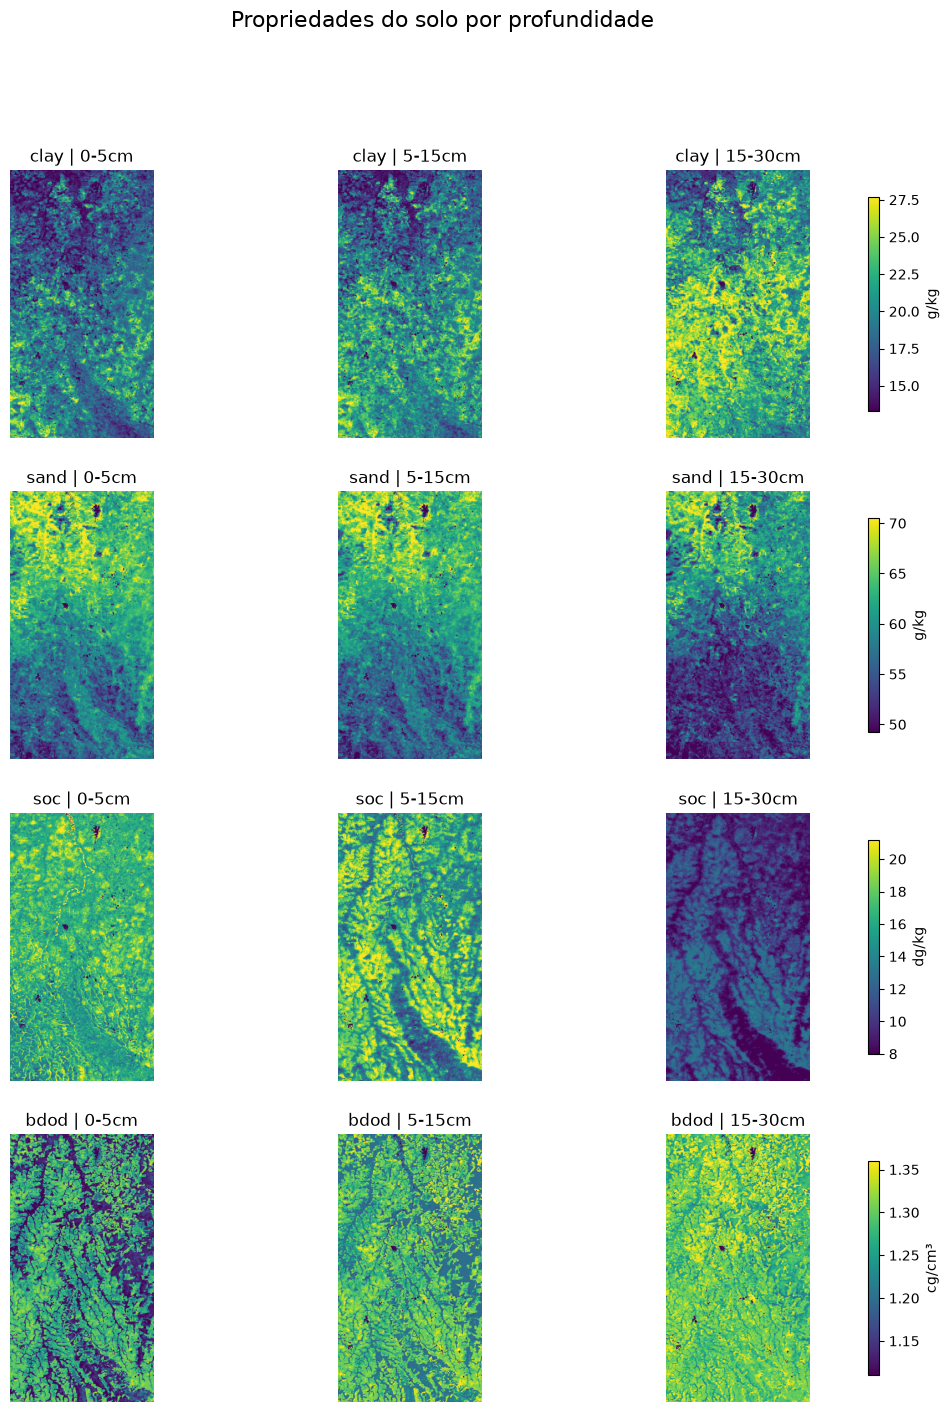

In [3]:
properties = ["clay", "sand", "soc", "bdod"]
depths = ["0-5cm", "5-15cm", "15-30cm"]
fig, axes = plt.subplots(len(properties), len(depths), figsize=(15, 16))
for row_index, property_name in enumerate(properties):
    property_arrays = []
    for depth in depths:
        path = next(
            item
            for item in RASTER_PATHS
            if f"property={property_name}" in str(item) and f"depth={depth}" in str(item)
        )
        with rasterio.open(path) as source:
            values = source.read(1, masked=True) / PROPERTY_METADATA[property_name]["factor"]
        property_arrays.append(values)
    valid = np.concatenate([values.compressed() for values in property_arrays])
    lower, upper = np.percentile(valid, [2, 98])
    for column_index, (depth, values) in enumerate(zip(depths, property_arrays, strict=True)):
        axis = axes[row_index, column_index]
        image = axis.imshow(values, cmap="viridis", vmin=lower, vmax=upper)
        axis.set_title(f"{property_name} | {depth}")
        axis.set_axis_off()
    fig.colorbar(
        image,
        ax=axes[row_index, :],
        label=PROPERTY_METADATA[property_name]["unit"],
        shrink=0.8,
    )
fig.suptitle("Propriedades do solo por profundidade", fontsize=16)
plt.show()

## Manifestos e rastreabilidade

A tabela final resume os manifestos dos 12 downloads. URL, cobertura WCS, bounding box, checksum e configuração permitem reproduzir e auditar cada raster independentemente.

In [4]:
manifest_rows = []
for path in sorted(SOIL_ROOT.glob("property=*/depth=*/*.manifest.json")):
    manifest = json.loads(path.read_text(encoding="utf-8"))
    manifest_rows.append(
        {
            "property": manifest.get("property"),
            "depth": manifest.get("depth"),
            "size_bytes": manifest.get("size_bytes"),
            "sha256": manifest.get("sha256"),
            "downloaded_at_utc": manifest.get("downloaded_at_utc"),
        }
    )
pd.DataFrame(manifest_rows)

,property,depth,size_bytes,sha256,downloaded_at_utc
0,bdod,0-5cm,263045,f852f6d6bf8b7ee9fafe2f14f31bcec3d2ac6f34364566...,2026-08-13T00:48:04.995114+00:00
1,bdod,15-30cm,239237,fcd75c57fb5d9c5a186c42f15f057de6b2fd14855653a6...,2026-08-13T00:48:07.335735+00:00
2,bdod,5-15cm,242234,3c860ed47062d373f3d962b7e7fa8d9ba8ef23ef70f960...,2026-08-13T00:48:06.069831+00:00
3,clay,0-5cm,390698,fec1be88e4035e50023c9aeecee477cdc2d3a6b2942449...,2026-08-13T00:47:51.077332+00:00
4,clay,15-30cm,399735,f994c38a197e0c2164102407980164e380dae338184433...,2026-08-13T00:47:54.360546+00:00
5,clay,5-15cm,396186,c7f49769f71b00e2cc76f8c46988232680d163006ab06f...,2026-08-13T00:47:52.724900+00:00
6,sand,0-5cm,399051,326173cc4f0595bae2594709b4aab97cf6ba0186463f1f...,2026-08-13T00:47:56.097388+00:00
7,sand,15-30cm,408221,c9f701a336175fe3865e978469f84f49c08e4664339ef0...,2026-08-13T00:47:59.478763+00:00
8,sand,5-15cm,397401,af70f65d7625d40fe3254a2acb00997166dda4d0499c98...,2026-08-13T00:47:57.736651+00:00
9,soc,0-5cm,367911,e24f6419187c06df9c7460ed1efe961d6faa137bdfff95...,2026-08-13T00:48:00.956513+00:00
